# Telco Customer Churn Analysis

**Dataset:** Telco Customer Churn — data from
[Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (7,043 customers, 21 columns)

**Goal:** Figure out why customers cancel their service, which contract and payment types are riskiest, and
how much money is at risk from the most vulnerable customer segment.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/ispiermacbook/Downloads/Telco_Customer_Churn.csv')
df.shape

(7043, 21)

## Step 0: Is the data clean?

**Why this matters:** Always check before trusting a dataset, especially when a column is supposed to be
a number but pandas loaded it as text - that's usually a sign something's hiding in there.


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total missing values:', df.isnull().sum().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate customer IDs:', df['customerID'].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


**Result so far:** No nulls, no duplicates - looks clean. But notice in `.info()` that `TotalCharges`
loaded as an `object` (text) column, even though it should be a number. That's suspicious enough to dig
into before moving on.


In [6]:
# TotalCharges should be numeric - find out why it isn't
bad_rows = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()]
print(f'{len(bad_rows)} rows have a TotalCharges value that is not a real number')
bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


11 rows have a TotalCharges value that is not a real number


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Result:** 11 customers have a blank `TotalCharges` value - and every single one of them
has `tenure = 0`, meaning they're brand-new customers who haven't been billed yet. This isn't broken data,
it's a logical gap: $0 total charges makes sense for someone who just signed up.

**Insight:** `.isnull().sum()` missed this entirely, because the blank value is an empty string, not a real
null. This is a good example of why `.info()` (checking data *types*) is just as important as checking for
nulls - a column that should be numeric but loaded as text is a red flag worth investigating every time.

**Recommendation:** Convert `TotalCharges` to a real number, and fill these 11 blanks with 0 (their logical
value), rather than dropping the rows - a new customer is still valid data for churn analysis.


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print('Fixed. New dtype:', df['TotalCharges'].dtype)
print('Any remaining nulls:', df['TotalCharges'].isnull().sum())

Fixed. New dtype: float64
Any remaining nulls: 0


## Question 1: What percent of customers churn overall?

**Business problem:** The baseline number every churn analysis starts with.

**Concept:** `value_counts(normalize=True)`

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


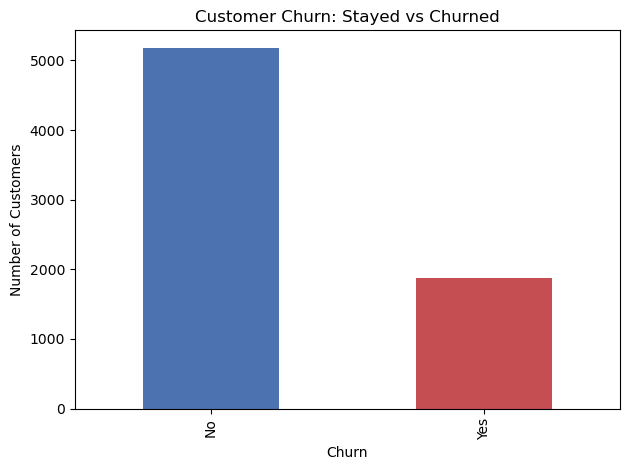

In [7]:
counts = df['Churn'].value_counts()
pct = df['Churn'].value_counts(normalize=True) * 100

print(counts)
print()
print(pct.round(1))

counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Customer Churn: Stayed vs Churned')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

**Result:** 1,869 of 7,043 customers churned -> **26.5%**.

**Insight:** A 26.5% churn rate is high, indicating that many customers are leaving.

**Recommendation:** Identify the main churn drivers by analyzing customer segments, tenure, plans, usage, and other relevant factors, then focus retention efforts on the high-risk groups.

---


## Question 2: Which contract type and payment method have the highest churn?

**Business problem:** Identify which contract types and payment methods are linked to higher churn so the company can focus on actionable retention strategies.

**Concept:** `groupby()` to calculate the churn rate for each contract type and payment method.


In [8]:
def churn_rate(data, col):
    rate = data.groupby(col, observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1)
    count = data.groupby(col, observed=True)['Churn'].count()
    return pd.DataFrame({'ChurnRate_%': rate, 'Count': count}).sort_values('ChurnRate_%', ascending=False)

contract_rate = churn_rate(df, 'Contract')
payment_rate = churn_rate(df, 'PaymentMethod')

print('--- By Contract Type ---')
print(contract_rate)
print('\n--- By Payment Method ---')
print(payment_rate)

--- By Contract Type ---
                ChurnRate_%  Count
Contract                          
Month-to-month         42.7   3875
One year               11.3   1473
Two year                2.8   1695

--- By Payment Method ---
                           ChurnRate_%  Count
PaymentMethod                                
Electronic check                  45.3   2365
Mailed check                      19.1   1612
Bank transfer (automatic)         16.7   1544
Credit card (automatic)           15.2   1522


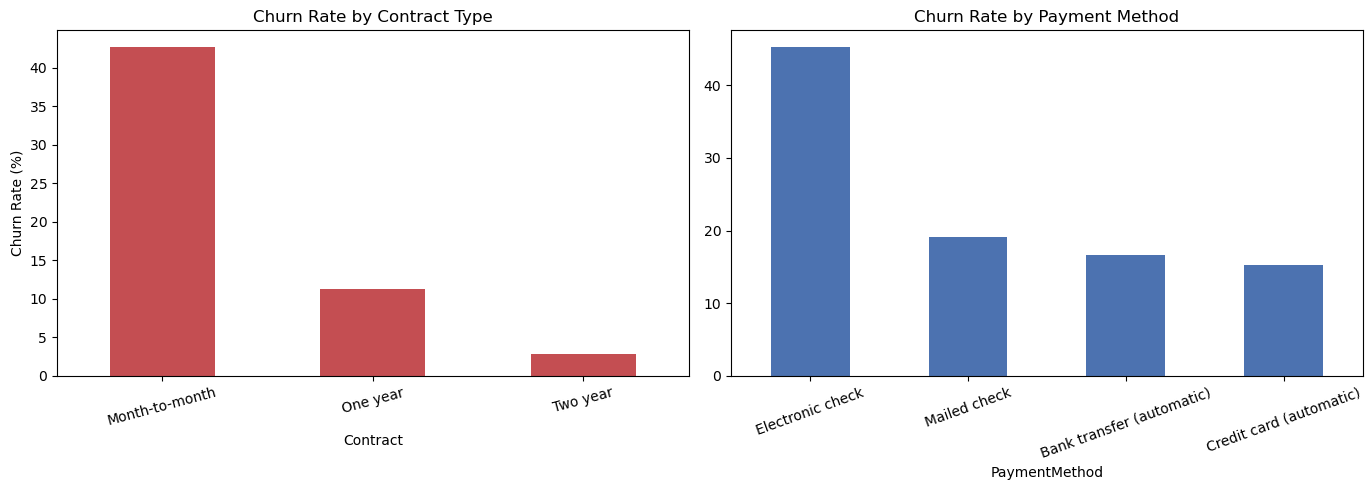

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_rate['ChurnRate_%'].plot(kind='bar', ax=axes[0], color='#C44E52')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)

payment_rate['ChurnRate_%'].plot(kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Result:** This is the sharpest pattern in the whole dataset. **Month-to-month contracts churn at
42.7%**, compared to **11.3% for one-year** and just **2.8% for two-year** contracts. **Electronic check**
payers churn at **45.3%**, more than double every other payment method (15-19%).

**Insight:** Contract length is the strongest pattern. Churn is much higher among month-to-month customers and much lower among customers on longer contracts.

Electronic check also shows high churn, but this may be a customer-segment effect rather than the payment method itself causing churn. This should be validated before concluding causation.

**Recommendation:** Focus retention efforts on month-to-month customers and test incentives such as annual-contract discounts or loyalty benefits. Also investigate why electronic-check customers churn more before treating the payment method itself as the cause.

---


## Question 3: Does how long someone's been a customer (tenure) predict churn?

**Business problem:** Find whether new customers churn more than long-term customers.

**Concept:** `pd.cut()` - splitting `tenure` (in months) into meaningful bands, and compare churn rates.


In [10]:
df['TenureBand'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 100],
                           labels=['0-12 months', '13-24 months', '25-48 months', '49+ months'])

tenure_rate = churn_rate(df, 'TenureBand')
print(tenure_rate)


              ChurnRate_%  Count
TenureBand                      
0-12 months          47.4   2186
13-24 months         28.7   1024
25-48 months         20.4   1594
49+ months            9.5   2239


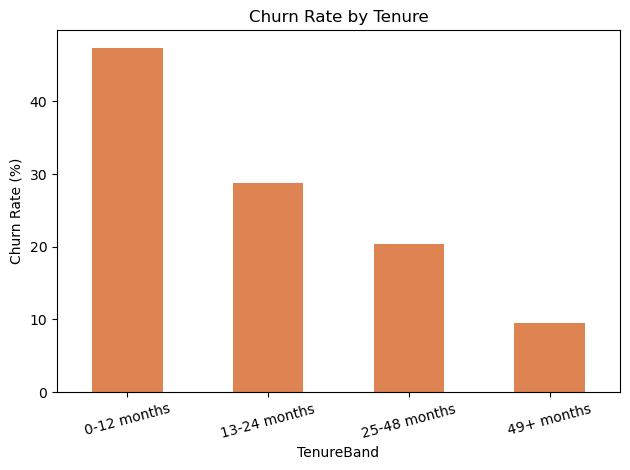

In [11]:
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
tenure_rate.loc[tenure_order]['ChurnRate_%'].plot(kind='bar', color='#DD8452')
plt.title('Churn Rate by Tenure')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Result:** Churn drops from **47.4%** in the first year, dropping to **28.7%**, then
**20.4%**, then just **9.5%** for customers with 49+ months of tenure.

**Insight:** Nearly half of brand-new customers churn within their first year - this is almost certainly
an onboarding problem, not a long-term problem. Customers who make it past year one become
dramatically more stable.

**Recommendation:** Focus retention effort specifically on the first 12 months - a strong onboarding
program or early loyalty incentive would target the single riskiest period in a customer's lifecycle.

---


## Question 4: What factors correlate most with churn overall?

**Business problem:** Find which numeric factors are most related to churn.

**Concept:** Use `corr()` - to check the correlation between numeric columns and Churn.


In [12]:
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_Flag']
corr_matrix = df[numeric_cols].corr()
churn_corr = corr_matrix['Churn_Flag'].drop('Churn_Flag').sort_values()
print(churn_corr.round(3))

tenure           -0.352
TotalCharges     -0.198
SeniorCitizen     0.151
MonthlyCharges    0.193
Name: Churn_Flag, dtype: float64


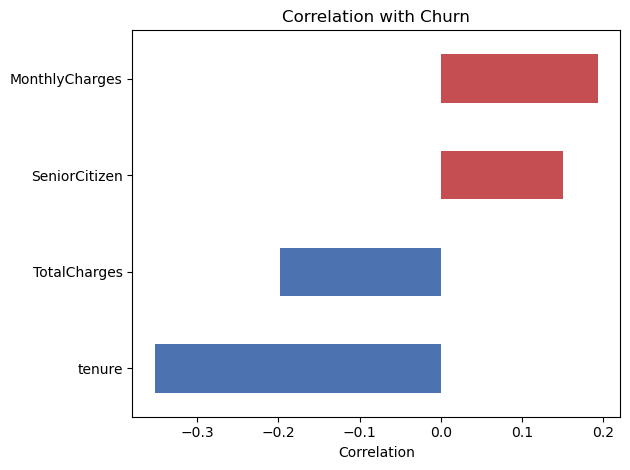

In [13]:
churn_corr.plot(kind='barh', color=['#C44E52' if v > 0 else '#4C72B0' for v in churn_corr])
plt.title('Correlation with Churn')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

**Result:** `tenure` is the strongest factor (**-0.35**). `MonthlyCharges` (+0.19) and senior citizen (+0.15) have weaker positive relationships with churn.
`TotalCharges` is negatively correlated (-0.20), but that's mostly a side effect of tenure - customers who
stick around longer naturally accumulate more total charges.

**Insight:** Tenure has the strongest relationship with churn, reinforcing that the *first year* is the highest-risk period.

---


## Question 5: Which service add-ons are linked to lower churn?

**Business problem:** Find whether customers using add-on services(online security, tech support, backup, device
protection) have lower churn.

**Concept:** Use `groupby()` on the four service columns and compare their churn rates.


--- OnlineSecurity ---
                     ChurnRate_%  Count
OnlineSecurity                         
No                          41.8   3498
Yes                         14.6   2019
No internet service          7.4   1526

--- TechSupport ---
                     ChurnRate_%  Count
TechSupport                            
No                          41.6   3473
Yes                         15.2   2044
No internet service          7.4   1526

--- OnlineBackup ---
                     ChurnRate_%  Count
OnlineBackup                           
No                          39.9   3088
Yes                         21.5   2429
No internet service          7.4   1526

--- DeviceProtection ---
                     ChurnRate_%  Count
DeviceProtection                       
No                          39.1   3095
Yes                         22.5   2422
No internet service          7.4   1526



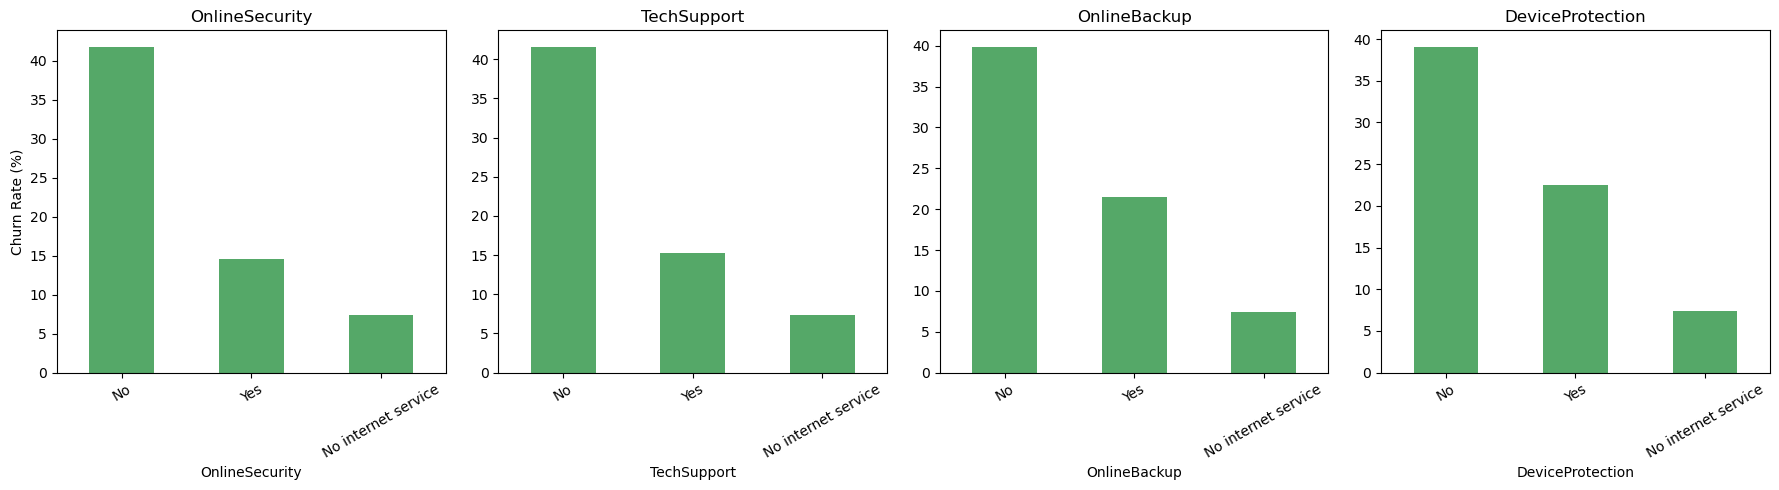

In [14]:
service_cols = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(service_cols):
    rate = churn_rate(df, col)
    print(f'--- {col} ---')
    print(rate)
    print()
    rate['ChurnRate_%'].plot(kind='bar', ax=axes[i], color='#55A868')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    if i == 0:
        axes[i].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

**Result:** Every single add-on shows the same pattern: customers **without** the service churn at
39-42%, while customers **with** it churn at just 15-23%. Customers with no internet service at all (so the
add-on doesn't apply) churn least of all, at 7.4%.

**Insight:** These add-ons aren't just extra revenue - they're strongly associated with retention. Whether
that's because the add-ons genuinely make the service stickier, or because customers who buy add-ons were
always going to be more loyal.

**Recommendation:** Bundle a free trial of these add-ons (especially Online Security and Tech Support, the
two strongest) into the first few months for new customers - it directly targets both the highest-risk
period (Q3) and a factor strongly linked to staying.

---


## Question 6: How much revenue is at risk from the highest-risk customer segment?

**Business problem:** Identify customers with the highest-risk combination and estimate their monthly revenue at risk.

**Concept:** A **business rule** (boolean logic) combining the three strongest risk factors found above,
then quantifying the revenue at stake using `MonthlyCharges` - the same "combine what you've proven" closing
move used in every project in this series.


In [15]:
# First: confirm this combination is actually higher risk than any single factor
combo = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['tenure'] < 12)
]

print("Customers:", len(combo))
print("Combo churn:", round((combo['Churn'] == 'Yes').mean() * 100, 1), "%")
print("Overall churn:", round((df['Churn'] == 'Yes').mean() * 100, 1), "%")

Customers: 876
Combo churn: 70.5 %
Overall churn: 26.5 %


In [16]:
# Now: how much MONTHLY revenue is at risk from the ACTIVE customers in this group
at_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['InternetService'] == 'Fiber optic') &
    (df['tenure'] < 12) &
    (df['Churn'] == 'No')
]

monthly = at_risk['MonthlyCharges'].sum()
annual = monthly * 12

print("Active high-risk customers:", len(at_risk))
print("Monthly revenue at risk:", round(monthly))
print("Annual revenue at risk:", round(annual))

Active high-risk customers: 258
Monthly revenue at risk: 20731
Annual revenue at risk: 248770


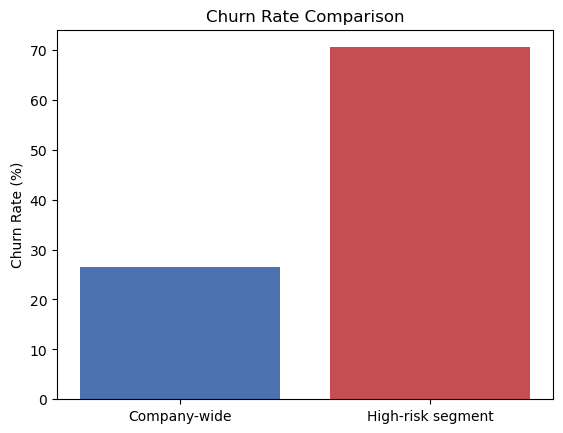

In [17]:
churn = [
    (df['Churn'] == 'Yes').mean() * 100,
    (combo['Churn'] == 'Yes').mean() * 100
]

plt.bar(['Company-wide', 'High-risk segment'], churn, color=['#4C72B0', '#C44E52'])
plt.title('Churn Rate Comparison')
plt.ylabel('Churn Rate (%)')
plt.show()

**Result:** Customers who are on a **month-to-month contract**, have **fiber optic internet**, and
have been a customer for **less than 12 months** churn at **70.5%** - nearly 3x the company-wide rate of
26.5%. There are **258 currently active customers** matching this exact profile, representing
**$248,770 in annual revenue** at risk.

**Insight:** This tiny, specific segment (258 out of 7,043 customers, under 4% of the base) carries a wildly
disproportionate amount of risk. This is a much sharper, more targeted finding than "reduce churn broadly" -
it points to one exact type of customer.

**Recommendation:** Target new, month-to-month, fiber customers with onboarding support, annual-plan incentives, or free add-on trials.

---


## Summary

| # | Question | What I Found |
|---|----------|---------------|
| 0 | Is the data clean? | Yes, once `TotalCharges` was fixed - 11 blank values were new customers with $0 billed so far |
| 1 | Overall churn rate | 26.5% (1,869 of 7,043) - high for this kind of business |
| 2 | Contract & payment method | Month-to-month churns at 42.7% vs 2.8% for two-year contracts; Electronic check payers churn at 45.3% |
| 3 | Does tenure matter? | Yes, a lot - 47.4% churn in year one, down to 9.5% after 49+ months |
| 4 | What correlates most? | Tenure by far, confirming Q3 |
| 5 | Do service add-ons help? | Yes - every add-on roughly halves churn risk for customers who have it |
| 6 | Highest-risk segment | New + month-to-month + fiber optic customers churn at 70.5% - $248,770/year in revenue at risk from just 258 active customers |

**Bottom line:** The churn problem is concentrated rather than evenly spread. The highest-risk group is new, month-to-month, fiber-optic customers.

**Recommendation:** Focus on first-year retention through better onboarding, annual-contract incentives, and targeted add-on trials.
